In [1]:
import logging
import time
import os
import pickle


import numpy as np
import matplotlib.pyplot as plt

#import tensorflow_datasets as tfds
import tensorflow as tf

# Import tf_text to load the ops used by the tokenizer saved model
#import tensorflow_text  # pylint: disable=unused-import
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split


from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Model,  Sequential
from tensorflow.keras.layers import LSTM, GRU, Bidirectional, Dropout, Input, TimeDistributed, Dense, Activation, RepeatVector, Embedding, Concatenate
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import Attention
from tensorflow.keras.optimizers import Adam, Adagrad
from keras.losses import sparse_categorical_crossentropy
logging.getLogger('tensorflow').setLevel(logging.ERROR)  # suppress warnings
import random

In [2]:
runs0 = [0, 1, 2, 3, 4, 5, 6, 8, 9, 10 ,11]
data0 = pd.read_csv('./BO_forHyperParameter/Arch1/InitialRound_HyperParameter.csv').iloc[runs0,1:].values
Headers = pd.read_csv('./BO_forHyperParameter/Arch1/InitialRound_HyperParameter.csv').iloc[:,1:].columns
result0 = np.zeros((len(runs0), 1))

for i in range(len(runs0)):
    filename = './EncDec_Arch1/Loss_Evolution/Initial/Combo' + str(runs0[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    
    result0[i] = output[-1,-2] *  output[-1,-1]
    
runs1 = [0, 1, 2]
data1 = pd.read_csv('./BO_forHyperParameter/Arch1/Round1.csv').iloc[runs1,1:].values
result1 = np.zeros((len(runs1), 1))

for i in range(len(runs1)):
    filename = './EncDec_Arch1/Loss_Evolution/Round1/Combo' + str(runs1[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result1[i] = output[-1,-2] *  output[-1,-1]
    
runs2 = [0, 1, 2]
data2 = pd.read_csv('./BO_forHyperParameter/Arch1/Round2.csv').iloc[runs2,1:].values
result2 = np.zeros((len(runs2), 1))

for i in range(len(runs2)):
    filename = './EncDec_Arch1/Loss_Evolution/Round2/Combo' + str(runs2[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result2[i] = output[-1,-2] *  output[-1,-1]

runs3 = [0, 1, 2]
data3 = pd.read_csv('./BO_forHyperParameter/Arch1/Round3.csv').iloc[runs3,1:].values
result3 = np.zeros((len(runs3), 1))

for i in range(len(runs3)):
    filename = './EncDec_Arch1/Loss_Evolution/Round3/Combo' + str(runs3[i]) + '.csv'
    output = pd.read_csv(filename).iloc[:,1:].values
    result3[i] = output[-1,-2] *  output[-1,-1]
    
data = np.concatenate((data0, data1, data2, data3), axis = 0)
result = np.concatenate((result0, result1, result2, result3), axis = 0)

In [3]:
Headers.tolist()

['Enc hidden size',
 'Enc Embedding size',
 'Dec Embedding size',
 'Dense Layer size',
 'Dense Layer size aa',
 'Drop rate',
 'Drop rate aa']

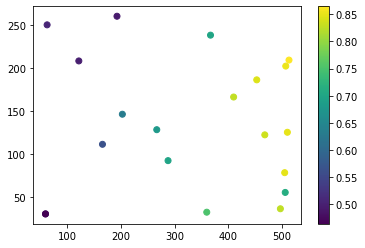

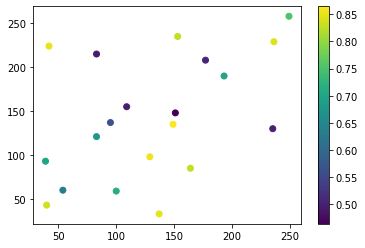

In [4]:
plt.figure()
plt.scatter(data[:,0],data[:,3], c = result[:,0])
plt.colorbar()
plt.figure()
plt.scatter(data[:,1],data[:,2], c = result[:,0])
plt.colorbar()

In [5]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# exclude class column if it exists
# data = df.values
data = data[:, [0,1,2,3,5, 4, 6]]

NameList = ['Enc. size', 'AA Embedding', 'Codon Embedding', 'Dense Layer size (CDS)', 'Dropout (CDS)', 
            'Dense Layer size (AA)', 'Dropout (AA)']
# Normalize for better visualization (optional)
data_min = data.min(axis=0)
data_max = data.max(axis=0)
data = (data - data_min) / (data_max - data_min)

In [14]:
cmap = matplotlib.cm.get_cmap('rocket_r')

params = {'axes.titlesize': 20, 'xtick.labelsize': 20, 'ytick.labelsize': 20, 'axes.labelsize': 20}
hfont = {'fontname':'Arial'}
plt.rcParams.update(params)
plt.rcParams["figure.figsize"] = (12, 8.1)
fig, axs = plt.subplots(1, 1) 
plt.gcf().subplots_adjust(bottom=0.4, left = 0.15)

# Plot
cnt_r = 0
for row in data:
    plt.plot(range(data.shape[1]), row, color= cmap(result[cnt_r]), linewidth = 1.5) #/np.max(result)
    cnt_r = cnt_r + 1
plt.xticks(range(data.shape[1]), NameList, rotation=45)
plt.ylabel("Scaled values")
# plt.colorbar()
plt.savefig("Hyperparameter_vs_accuracy.pdf", dpi = 300)

TypeError: unsupported operand type(s) for *: 'ListedColormap' and 'int'

In [7]:
result[cnt_r-1]

array([0.83339998])

In [8]:
data

array([[0.77262693, 0.5952381 , 0.23111111, 0.59130435, 0.11111111,
        0.3231441 , 0.55555556],
       [0.31567329, 0.07142857, 0.12      , 0.50434783, 0.        ,
        0.10480349, 0.88888889],
       [0.86754967, 0.93809524, 0.87111111, 0.67826087, 0.66666667,
        0.34934498, 0.66666667],
       [0.67770419, 0.73333333, 0.69777778, 0.90434783, 1.        ,
        0.        , 0.11111111],
       [0.00662252, 0.65714286, 0.77777778, 0.95652174, 0.22222222,
        0.58078603, 0.66666667],
       [0.13686534, 0.33333333, 0.54222222, 0.77391304, 0.66666667,
        0.66812227, 1.        ],
       [0.50331126, 0.        , 0.26666667, 0.26956522, 0.55555556,
        0.44978166, 0.22222222],
       [0.45695364, 0.20952381, 0.39111111, 0.42608696, 0.44444444,
        0.88209607, 0.33333333],
       [0.23399558, 0.26666667, 0.46222222, 0.35217391, 0.77777778,
        0.77729258, 0.77777778],
       [0.66225166, 1.        , 1.        , 0.00869565, 0.22222222,
        0.23144105, 0.3